In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns
from pathlib import Path

In [2]:
DATA_PATH=Path('../data/raw/public_transport_delays.csv')
df=pd.read_csv(DATA_PATH)

In [3]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 24 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   trip_id                     2000 non-null   str    
 1   date                        2000 non-null   str    
 2   time                        2000 non-null   str    
 3   transport_type              2000 non-null   str    
 4   route_id                    2000 non-null   str    
 5   origin_station              2000 non-null   str    
 6   destination_station         2000 non-null   str    
 7   scheduled_departure         2000 non-null   str    
 8   scheduled_arrival           2000 non-null   str    
 9   actual_departure_delay_min  2000 non-null   int64  
 10  actual_arrival_delay_min    2000 non-null   int64  
 11  weather_condition           2000 non-null   str    
 12  temperature_C               2000 non-null   float64
 13  humidity_percent            2000 non-null   

In [4]:
print(df.shape)

(2000, 24)


In [5]:
print(df.sample(5))

     trip_id        date      time transport_type  route_id origin_station  \
664   T00664  2023-01-08  03:00:00            Bus  Route_14     Station_33   
658   T00658  2023-01-08  01:30:00          Metro  Route_19      Station_5   
1451  T01451  2023-01-16  07:45:00            Bus   Route_3     Station_32   
1798  T01798  2023-01-19  22:30:00           Tram  Route_13      Station_6   
1748  T01748  2023-01-19  10:00:00           Tram  Route_11     Station_20   

     destination_station scheduled_departure scheduled_arrival  \
664           Station_10            03:04:00          03:20:00   
658           Station_18            01:34:00          02:02:00   
1451          Station_33            07:46:00          08:37:00   
1798          Station_21            22:34:00          22:59:00   
1748          Station_38            10:04:00          10:49:00   

      actual_departure_delay_min  ...  wind_speed_kmh precipitation_mm  \
664                           16  ...              29       

In [6]:
df.isnull().sum()

trip_id                          0
date                             0
time                             0
transport_type                   0
route_id                         0
origin_station                   0
destination_station              0
scheduled_departure              0
scheduled_arrival                0
actual_departure_delay_min       0
actual_arrival_delay_min         0
weather_condition                0
temperature_C                    0
humidity_percent                 0
wind_speed_kmh                   0
precipitation_mm                 0
event_type                    1173
event_attendance_est             0
traffic_congestion_index         0
holiday                          0
peak_hour                        0
weekday                          0
season                           0
delayed                          0
dtype: int64

In [7]:
df.describe()

,actual_departure_delay_min,actual_arrival_delay_min,temperature_C,humidity_percent,wind_speed_kmh,precipitation_mm,event_attendance_est,traffic_congestion_index,holiday,peak_hour,weekday,delayed
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,8.688000,13.318000,15.121350,64.714000,29.300500,9.860700,6420.250000,50.244000,0.089500,0.272000,2.976000,0.749500
std,6.268118,9.289727,11.479424,20.334747,17.264015,5.781373,15198.306129,29.225751,0.285535,0.445101,1.990328,0.433409
min,-2.000000,-3.000000,-5.000000,30.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.000000,5.000000,5.100000,46.000000,15.000000,4.900000,0.000000,25.000000,0.000000,0.000000,1.000000,0.000000
50%,9.000000,13.000000,15.300000,65.000000,29.000000,9.700000,0.000000,50.000000,0.000000,0.000000,3.000000,1.000000
75%,14.000000,21.000000,24.800000,83.000000,45.000000,14.800000,2000.000000,76.000000,0.000000,1.000000,5.000000,1.000000
max,19.000000,29.000000,35.000000,99.000000,59.000000,20.000000,50000.000000,99.000000,1.000000,1.000000,6.000000,1.000000


In [8]:
df['event_type']=df['event_type'].fillna('No events')

In [9]:
df['date'] = pd.to_datetime(df['date'])
df['time'] = pd.to_datetime(df['time'], format='%H:%M:%S').dt.time

In [10]:
df.sample(5)

,trip_id,date,time,transport_type,route_id,origin_station,destination_station,scheduled_departure,scheduled_arrival,actual_departure_delay_min,...,wind_speed_kmh,precipitation_mm,event_type,event_attendance_est,traffic_congestion_index,holiday,peak_hour,weekday,season,delayed
671,T00671,2023-01-08,04:45:00,Train,Route_8,Station_23,Station_21,04:48:00,05:29:00,19,...,33,9.7,Sports,10000,8,0,0,6,Spring,1
1561,T01561,2023-01-17,11:15:00,Metro,Route_13,Station_32,Station_21,11:16:00,11:36:00,19,...,9,4.3,No events,50000,35,0,1,1,Spring,1
1482,T01482,2023-01-16,15:30:00,Train,Route_15,Station_31,Station_33,15:31:00,16:19:00,18,...,57,5.2,Festival,0,94,0,0,0,Winter,0
1451,T01451,2023-01-16,07:45:00,Bus,Route_3,Station_32,Station_33,07:46:00,08:37:00,13,...,14,9.2,Concert,10000,49,0,0,0,Spring,1
928,T00928,2023-01-10,21:00:00,Train,Route_4,Station_42,Station_45,21:00:00,21:20:00,19,...,1,11.9,No events,50000,32,0,0,1,Autumn,1


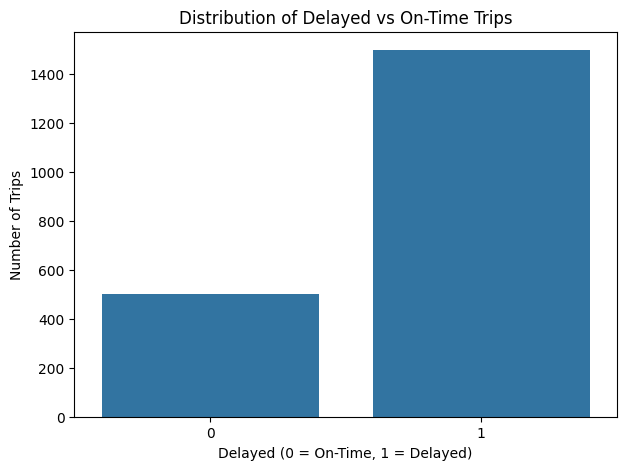

In [11]:
plt.figure(figsize=(7,5))
sns.countplot(data=df,x='delayed')
plt.title('Distribution of Delayed vs On-Time Trips')
plt.xlabel('Delayed (0 = On-Time, 1 = Delayed)')
plt.ylabel('Number of Trips')
plt.show()

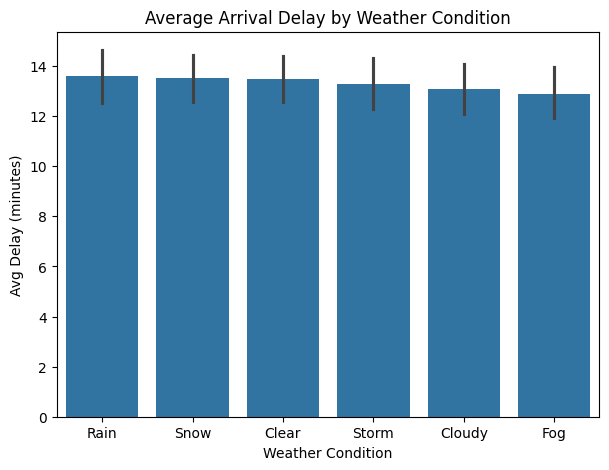

In [12]:
x=df.groupby('weather_condition')['actual_arrival_delay_min'].mean().sort_values(ascending=False)
plt.figure(figsize=(7,5))
sns.barplot(data=df,x='weather_condition',y='actual_arrival_delay_min',order=x.sort_values(ascending=False).index)
plt.title('Average Arrival Delay by Weather Condition')
plt.xlabel('Weather Condition')
plt.ylabel('Avg Delay (minutes)')
plt.show()

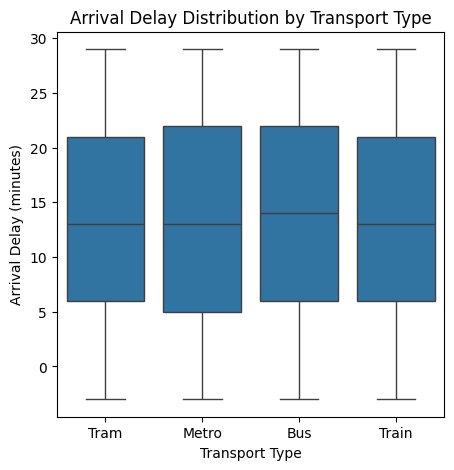

In [13]:
plt.figure(figsize=(5,5))
sns.boxplot(data=df,x='transport_type',y='actual_arrival_delay_min' )
plt.title('Arrival Delay Distribution by Transport Type')
plt.xlabel('Transport Type')
plt.ylabel('Arrival Delay (minutes)')
plt.show()

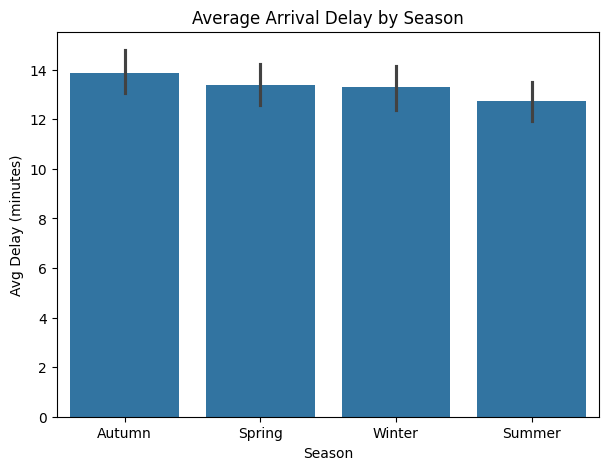

In [14]:
x=df.groupby('season')['actual_arrival_delay_min'].mean().sort_values(ascending=False)
plt.figure(figsize=(7,5))
sns.barplot(data=df,x='season',y='actual_arrival_delay_min',order=x.sort_values(ascending=False).index)
plt.title('Average Arrival Delay by Season')
plt.xlabel('Season')
plt.ylabel('Avg Delay (minutes)')
plt.show()

In [15]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 24 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   trip_id                     2000 non-null   str           
 1   date                        2000 non-null   datetime64[us]
 2   time                        2000 non-null   object        
 3   transport_type              2000 non-null   str           
 4   route_id                    2000 non-null   str           
 5   origin_station              2000 non-null   str           
 6   destination_station         2000 non-null   str           
 7   scheduled_departure         2000 non-null   str           
 8   scheduled_arrival           2000 non-null   str           
 9   actual_departure_delay_min  2000 non-null   int64         
 10  actual_arrival_delay_min    2000 non-null   int64         
 11  weather_condition           2000 non-null   str           
 12  tem